Data Overview:
   hour_of_day  day_of_week  is_weekend  population_density  \
0            6            1           0         8619.029837   
1           19            3           1         2051.525442   
2           14            5           1         1305.183231   
3           10            6           0         5239.113849   
4            7            1           1         4996.526953   

   public_transport_coverage  number_intersections  weather_condition  \
0                   0.544007                    38                  1   
1                   0.136062                     8                  2   
2                   0.985890                    42                  1   
3                   0.445133                    11                  0   
4                   0.237005                    11                  0   

   special_event  previous_traffic_flow  traffic_flow  congestion_level  
0              0            1061.945651   2008.313547                 2  
1              0   

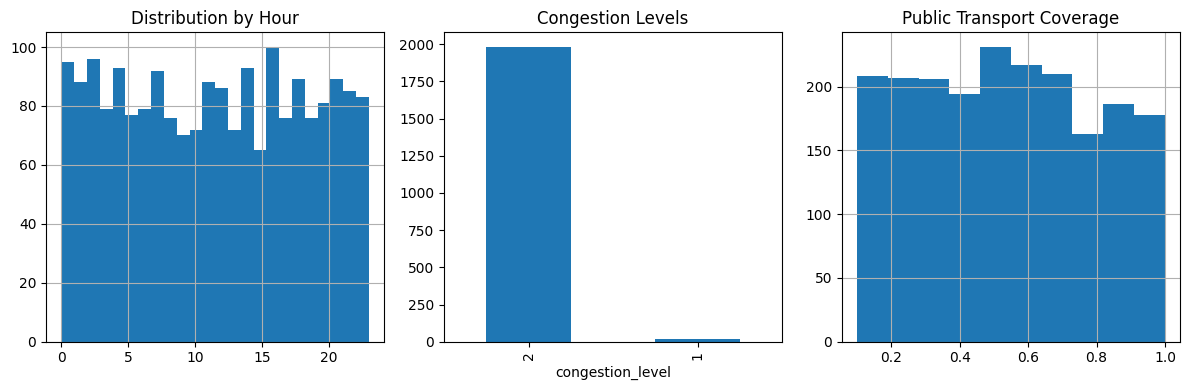

Regression Model Performance:
MAE: 73.68
RMSE: 92.30
Clustering completed with 3 clusters

Cluster Analysis Summary:
        traffic_flow         congestion_level public_transport_coverage  \
                mean     std             mean                      mean   
cluster                                                                   
0            2190.21  246.63             2.00                      0.53   
1            1788.73  244.51             1.99                      0.59   
2            1746.12  234.72             1.99                      0.48   

        population_density  
                      mean  
cluster                     
0                  4854.76  
1                  4999.47  
2                  4897.35  

DATA-DRIVEN URBAN PLANNING RECOMMENDATIONS

Cluster 0 Analysis:
  - Average Traffic Flow: 2190 vehicles/hour
  - Average Congestion Level: 2.0/2
  - Public Transport Coverage: 0.53
  Recommendation: HIGH PRIORITY: Implement congestion pricing, expand public

In [1]:
# Cell 1: Import and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from traffic_optimization import UrbanTrafficOptimizer

# Cell 2: Initialize and generate data
optimizer = UrbanTrafficOptimizer()
df = optimizer.generate_sample_data(2000)
print("Data Overview:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

# Cell 3: Data exploration
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df['hour_of_day'].hist(bins=24)
plt.title('Distribution by Hour')

plt.subplot(1, 3, 2)
df['congestion_level'].value_counts().plot(kind='bar')
plt.title('Congestion Levels')

plt.subplot(1, 3, 3)
df['public_transport_coverage'].hist()
plt.title('Public Transport Coverage')
plt.tight_layout()
plt.show()

# Cell 4: Train models and analyze
X, y_flow, y_congestion = optimizer.preprocess_data(df)
X_test, y_test, y_pred = optimizer.train_regression_model(X, y_flow)
clusters = optimizer.train_clustering_model(X)
cluster_summary = optimizer.analyze_traffic_patterns(df, clusters)

# Cell 5: Generate recommendations
recommendations = optimizer.generate_recommendations(cluster_summary)